## Example colocating EarthCARE and lightning cluster

In [1]:
!pip install s3fs scikit-learn stratify

In [2]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from IPython.display import Image, display
import pathlib
import os
from pathlib import Path
import requests
import aiohttp

# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

### Process:
 - Find lightning clusters for each file from `EC_lightning_clusters.parquet`
 - Get lightning counts along-track from `EC_track_lightning_LI.parquet`
 - Find 256 points along CPR track around peak
 - Search for EarthCARE data product and read into `xarray.Dataset`
 - Colocate EarthCARE points and regrid to standard height levels

## Find lightning cluster

In [3]:
selected_file = 'EC_lightning_clusters.parquet'
earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id), ('source', "==", "LI")],
)
gdf

,unique_id,earthcare_id,source,parent_cluster_id,cluster_id,surface_type,peak_datetime,peak_lat,peak_lon,peak_lightning,...,cluster_area_km2,cluster_mean_lat,cluster_mean_lon,cluster_dist_km,first_lightning_min,last_lightning_min,duration_min,travel_km,missing_peak_minutes,geometry
0,01101E_LI_0,01101E,LI,5,0,land,2024-08-07 17:49:47.641487616+00:00,-19.374586,-59.341534,1,...,150.0,-19.415436,-59.256775,9.583754,-23,10,34,50.396728,0.0,POINT (-59.34153 -19.37459)


In [4]:
selected_file_track = 'EC_track_lightning_LI.parquet'
earthcare_id = "01101E"

gdf_track = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file_track}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id)],
)
gdf_track

,cluster_id,lightning_count_2p5,lightning_count_5,time,land_flag,earthcare_id,source,geometry
0,0,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
1,1,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
2,2,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
3,0,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
4,1,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
...,...,...,...,...,...,...,...,...
14695,1,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14696,2,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14697,0,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)
14698,1,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)


## Find total lightning counts (along track) for all clusters:

In [5]:
total_lightning_counts = gdf_track.lightning_count_2p5.groupby(gdf_track.geometry).sum().reset_index()
total_lightning_counts = gpd.GeoDataFrame(total_lightning_counts)

<Axes: >

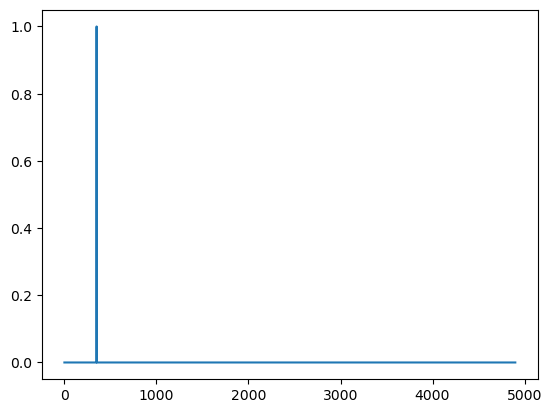

In [6]:
total_lightning_counts.lightning_count_2p5.plot()

In [13]:
type(gdf.geometry[0])

shapely.geometry.point.Point

Find nearest point to cluster centre:

In [7]:
nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()
nearest_point

/tmp/ipykernel_885/2032463108.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()


np.int64(349)

In [8]:
lightning_patch = total_lightning_counts.loc[349-128:349+127]

## Find EarthCARE data

In [9]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

In [10]:
# --- Path to credentials.txt --- 
CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

In [11]:
token = get_token()

p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE


## Search for and load CPR corrected doppler file

In [130]:
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)


In [131]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="(productType = 'ACM_CAP_2B') and orbitNumber = 01101 and frame = 'E'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries
    method = 'GET', # This is necessary 
    max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list
acmcap_ds = xr.open_dataset(
    fs.open(items[0].assets.get('enclosure_h5').href, "rb"), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    group="ScienceData"
)

In [132]:
acmcap_ds

<xarray.Dataset> Size: 559MB
Dimensions:                                                         (
                                                                     along_track: 4930,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 39kB ...
    latitude                                                        (along_track) float64 39kB ...
    longitude                                                       (along_track) float64 39kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

For now, let's work with a single variable: `doppler_velocity_best_estimate`

In [134]:
acmcap = acmcap_ds.set_coords(["time", "latitude", "longitude", "height"])[
    [
        "ice_water_content", 
        "ice_mass_flux", 
        "ice_effective_radius", 
        "ice_median_volume_diameter", 
        "ice_riming_factor", 
        "rain_rate", 
        "rain_water_content", 
        "rain_median_volume_diameter", 
        "liquid_water_content", 
        "liquid_number_concentration", 
        "liquid_effective_radius", 
    ]
]

In [135]:
acmcap

<xarray.Dataset> Size: 57MB
Dimensions:                      (along_track: 4930, JSG_height: 242)
Coordinates:
    time                         (along_track) datetime64[ns] 39kB ...
    latitude                     (along_track) float64 39kB ...
    longitude                    (along_track) float64 39kB ...
    height                       (along_track, JSG_height) float32 5MB ...
Dimensions without coordinates: along_track, JSG_height
Data variables:
    ice_water_content            (along_track, JSG_height) float32 5MB ...
    ice_mass_flux                (along_track, JSG_height) float32 5MB ...
    ice_effective_radius         (along_track, JSG_height) float32 5MB ...
    ice_median_volume_diameter   (along_track, JSG_height) float32 5MB ...
    ice_riming_factor            (along_track, JSG_height) float32 5MB ...
    rain_rate                    (along_track, JSG_height) float32 5MB ...
    rain_water_content           (along_track, JSG_height) float32 5MB ...
    rain_median_volume_diameter  (along_track, JSG_height) float32 5MB ...
    liquid_water_content         (along_track, JSG_height) float32 5MB ...
    liquid_number_concentration  (along_track, JSG_height) float32 5MB ...
    liquid_effective_radius      (along_track, JSG_height) float32 5MB ...

## Colocate EarthCARE and lightning data

EarthCARE files have different horizontal resolutions and heights, so we will find nearest neighbours (spatially) to the lightning points, and regrid the height levels to a standard set of heights

In [136]:
# Create a balltree object to efficiently find nearest neighbours
import numpy as np
from sklearn.neighbors import BallTree
cpr_ll_tree = BallTree(
    np.radians(np.stack(
        [
            acmcap.latitude.values, 
            acmcap.longitude.values,
        ], axis=1
    )), 
    metric="haversine", 
)

In [137]:
patch_ll = np.radians(np.stack(
    [
        lightning_patch.geometry.y, 
        lightning_patch.geometry.x,
    ], axis=1
))

In [138]:
distances, neighbours = cpr_ll_tree.query(
    patch_ll
)

In [139]:
# Now use neighbours to select CCD columns:
acmcap_patch = acmcap.isel(along_track=neighbours.ravel())

In [140]:
acmcap_patch

<xarray.Dataset> Size: 3MB
Dimensions:                      (along_track: 256, JSG_height: 242)
Coordinates:
    time                         (along_track) datetime64[ns] 2kB ...
    latitude                     (along_track) float64 2kB -20.37 ... -18.02
    longitude                    (along_track) float64 2kB -59.54 ... -59.07
    height                       (along_track, JSG_height) float32 248kB ...
Dimensions without coordinates: along_track, JSG_height
Data variables:
    ice_water_content            (along_track, JSG_height) float32 248kB ...
    ice_mass_flux                (along_track, JSG_height) float32 248kB ...
    ice_effective_radius         (along_track, JSG_height) float32 248kB ...
    ice_median_volume_diameter   (along_track, JSG_height) float32 248kB ...
    ice_riming_factor            (along_track, JSG_height) float32 248kB ...
    rain_rate                    (along_track, JSG_height) float32 248kB ...
    rain_water_content           (along_track, JSG_height) float32 248kB ...
    rain_median_volume_diameter  (along_track, JSG_height) float32 248kB ...
    liquid_water_content         (along_track, JSG_height) float32 248kB ...
    liquid_number_concentration  (along_track, JSG_height) float32 248kB ...
    liquid_effective_radius      (along_track, JSG_height) float32 248kB ...

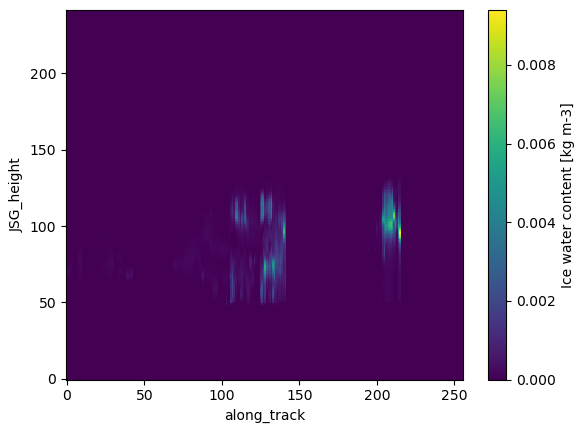

In [141]:
acmcap_patch.ice_water_content.T[::-1].plot()

Now we need to interpolate to a new, standard set of height levels:

In [142]:
new_heights = np.arange(50,2e4,100)

In [144]:
patch_ds = xr.Dataset(
    coords = dict(
        time=ccd_patch.time,
        latitude=ccd_patch.latitude,
        longitude=ccd_patch.longitude,
        height=xr.DataArray(new_heights, dims="height")
    ),
)

In [145]:
patch_ds["lightning_count_2p5"] = ("along_track", lightning_patch.lightning_count_2p5.to_numpy())

In [146]:
acmcap.data_vars

Data variables:
    ice_water_content            (along_track, JSG_height) float32 5MB ...
    ice_mass_flux                (along_track, JSG_height) float32 5MB ...
    ice_effective_radius         (along_track, JSG_height) float32 5MB ...
    ice_median_volume_diameter   (along_track, JSG_height) float32 5MB ...
    ice_riming_factor            (along_track, JSG_height) float32 5MB ...
    rain_rate                    (along_track, JSG_height) float32 5MB ...
    rain_water_content           (along_track, JSG_height) float32 5MB ...
    rain_median_volume_diameter  (along_track, JSG_height) float32 5MB ...
    liquid_water_content         (along_track, JSG_height) float32 5MB ...
    liquid_number_concentration  (along_track, JSG_height) float32 5MB ...
    liquid_effective_radius      (along_track, JSG_height) float32 5MB ...

In [149]:
import stratify

for var in acmcap_patch.data_vars:
    da = acmcap_patch[var]
    patch_ds[var] = (
        ("along_track", "height"), 
        stratify.interpolate(
            new_heights[::-1],
            da.height.fillna(-np.inf).values,
            da.values,
            axis=1,
            rising=False
        )
    )

In [151]:
patch_ds

<xarray.Dataset> Size: 2MB
Dimensions:                      (along_track: 256, height: 200)
Coordinates:
    time                         (along_track) datetime64[ns] 2kB ...
    latitude                     (along_track) float64 2kB -20.37 ... -18.02
    longitude                    (along_track) float64 2kB -59.54 ... -59.07
  * height                       (height) float64 2kB 50.0 150.0 ... 1.995e+04
Dimensions without coordinates: along_track
Data variables:
    lightning_count_2p5          (along_track) uint32 1kB 0 0 0 0 0 ... 0 0 0 0
    ice_water_content            (along_track, height) float32 205kB 0.0 ... 0.0
    ice_mass_flux                (along_track, height) float32 205kB 0.0 ... 0.0
    ice_effective_radius         (along_track, height) float32 205kB nan ... nan
    ice_median_volume_diameter   (along_track, height) float32 205kB nan ... nan
    ice_riming_factor            (along_track, height) float32 205kB 0.0 ... 0.0
    rain_rate                    (along_track, height) float32 205kB nan ... nan
    rain_water_content           (along_track, height) float32 205kB nan ... nan
    rain_median_volume_diameter  (along_track, height) float32 205kB nan ... nan
    liquid_water_content         (along_track, height) float32 205kB 0.0 ... 0.0
    liquid_number_concentration  (along_track, height) float32 205kB 0.0 ... 0.0
    liquid_effective_radius      (along_track, height) float32 205kB nan ... nan

## Compare lightning counts to ACM CAP

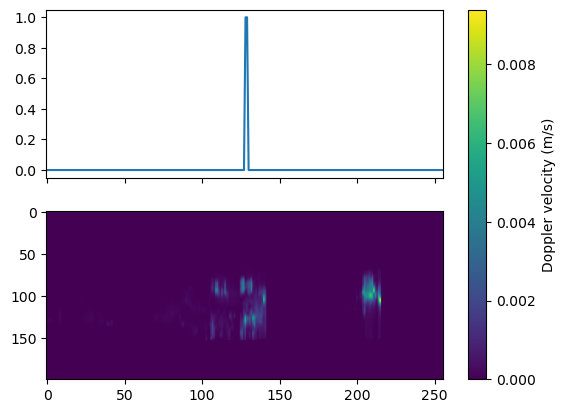

In [153]:
fig, axes = plt.subplots(2,1,sharex=True)

line = axes[0].plot(lightning_patch.lightning_count_2p5.to_numpy())
image = axes[1].imshow(patch_ds.ice_water_content.T, aspect="auto")#, cmap="RdBu_r", vmin=-5, vmax=5)

plt.colorbar(image, ax=axes, orientation="vertical", label="Doppler velocity (m/s)")